# Random Forest — Difficult Airway Prediction
Baseline model for comparison.

In [8]:
import warnings, numpy as np, pandas as pd, time, joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
warnings.filterwarnings("ignore")
ROOT = Path.cwd()

In [9]:
# Load dataset
df = pd.read_excel(ROOT / "D:\Minor_Project\dataset.xlsx")
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} cols")
print(f"Target distribution:\n{df['Target'].value_counts().sort_index()}")

Dataset: 2500 rows, 31 cols
Target distribution:
Target
0    833
1    834
2    833
Name: count, dtype: int64


In [10]:
# Preprocessing (same as XGBoost)
CAT_COLS = ["Gender","Previous_Airway_Records","Disease_Arthritis","Disease_Diabetes","Disease_Down_Syndrome",
    "Breathing_Snoring","Breathing_Sleep_Apnea","Symptom_Voice_Changes","Symptom_Difficulty_Swallowing",
    "Symptom_Cant_Lie_Flat","Injury_Swelling","Injury_Previous_Neck_Fracture","Previous_Emergencies_ICU",
    "BMI_Category","Beard","Chest_Size","Neck_Structure","Mallampati_Score","TMD_Category",
    "Jaw_Movement","Neck_Movement_Category","Tissue_Flexibility"]
TARGET = "Target"

X = df.drop(columns=["Patient_ID", TARGET])
y = df[TARGET].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_val[col], X_test[col]]).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

Train: 1750, Val: 375, Test: 375


In [11]:
# Train Random Forest
model = RandomForestClassifier(
    n_estimators=500, max_depth=12, min_samples_leaf=4,
    class_weight="balanced", n_jobs=-1, random_state=42,
)

start = time.time()
model.fit(X_train, y_train)
elapsed = time.time() - start
print(f"\nTraining time: {elapsed:.2f}s")

joblib.dump(model, str(ROOT / "D:/Minor_Project/checkpoints/randomforest_best.pkl"))
print("Model saved to checkpoints/randomforest_best.pkl")


Training time: 0.86s
Model saved to checkpoints/randomforest_best.pkl


In [12]:
# Evaluate
y_preds = model.predict(X_test)
y_probs = model.predict_proba(X_test)
cm = confusion_matrix(y_test, y_preds)

print(classification_report(y_test, y_preds, target_names=["Easy","Moderate","Difficult"], digits=3))
print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy: {(y_preds==y_test).mean():.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_probs, multi_class='ovr'):.4f}")

              precision    recall  f1-score   support

        Easy      0.864     0.816     0.840       125
    Moderate      0.697     0.792     0.742       125
   Difficult      0.904     0.832     0.867       125

    accuracy                          0.813       375
   macro avg      0.822     0.813     0.816       375
weighted avg      0.822     0.813     0.816       375

Confusion Matrix:
[[102  22   1]
 [ 16  99  10]
 [  0  21 104]]

Accuracy: 0.8133
AUC-ROC:  0.9528


In [13]:
# Feature Importance
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1][:10]
print("Top 10 features:")
for i in sorted_idx:
    print(f"  {X_train.columns[i]}: {importances[i]:.3f}")

Top 10 features:
  Mallampati_Score: 0.311
  Thyromental_Distance_TMD_cm: 0.153
  TMD_Category: 0.095
  BMI: 0.088
  Neck_Circumference_cm: 0.059
  BMI_Category: 0.047
  Neck_Movement_Degrees: 0.045
  Neck_Structure: 0.036
  Age: 0.030
  Sternomental_Distance_SMD_cm: 0.025


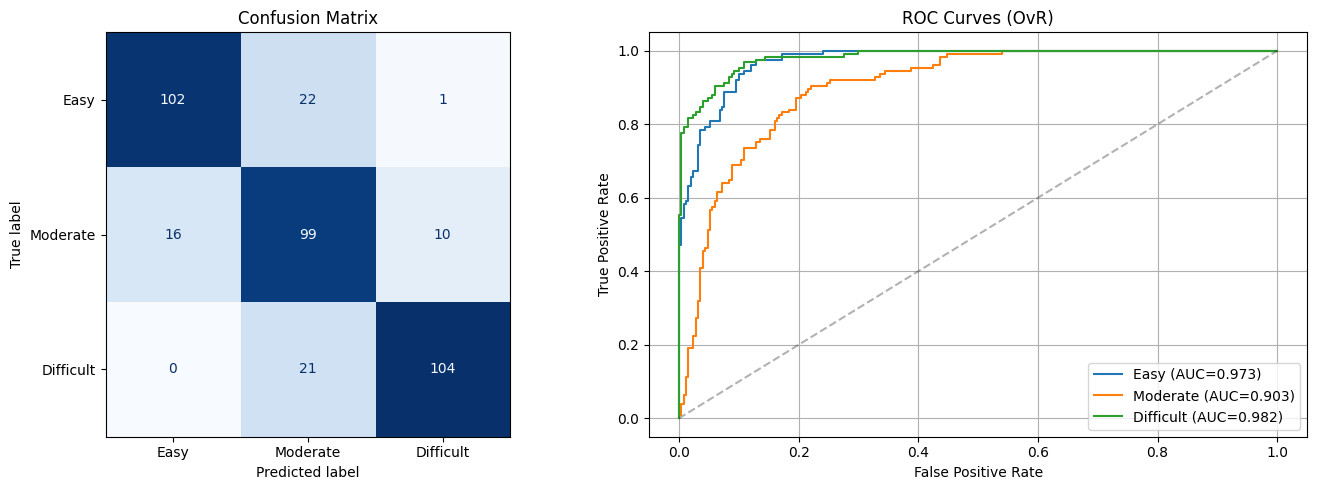

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

# Check if y_preds and y_probs exist
if 'y_preds' not in globals() or 'y_probs' not in globals():
    print("y_preds and/or y_probs are not defined. Please re-run the evaluation cell before plotting.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_preds,
        display_labels=["Easy", "Moderate", "Difficult"],
        cmap="Blues", ax=axes[0], colorbar=False,
    )
    axes[0].set_title("Confusion Matrix")

    # ROC Curves
    ax = axes[1]
    classes = ["Easy", "Moderate", "Difficult"]
    for i in range(3):
        y_bin = (y_test == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves (OvR)")
    ax.legend(loc="lower right")
    ax.grid(True)

    plt.tight_layout()
    plt.show()